In [1]:
import sys 
import os 

import minari 
import gymnasium
import matplotlib.pyplot as plt 
#from IPython.display import display, clear_output
import torch 
import numpy as np

from data.TrajectorySet import TrajectorySet 
import os
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
dataset = minari.load_dataset("D4RL/pointmaze/large-v2") 
env = dataset.recover_environment(render_mode="rgb_array") 


In [3]:
T = TrajectorySet(dataset=dataset) 

T.generate_trajectories(n_trajectories=1)
trajectory = T.get_trajectory(index=0)
xy_states = trajectory[0][:, :2]

In [4]:
def world_to_image_coords(xy, img_width, img_height, x_bounds=(-5, 5), y_bounds=(-3.5, 3.5)):
    x, y = xy.T
    # Normalize x/y to [0, 1]
    x_norm = (x - x_bounds[0]) / (x_bounds[1] - x_bounds[0])
    y_norm = (y - y_bounds[0]) / (y_bounds[1] - y_bounds[0])

    # Map to pixel space
    x_pixel = x_norm * img_width
    y_pixel = (1 - y_norm) * img_height  # flip y-axis

    return np.stack([x_pixel, y_pixel], axis=1)



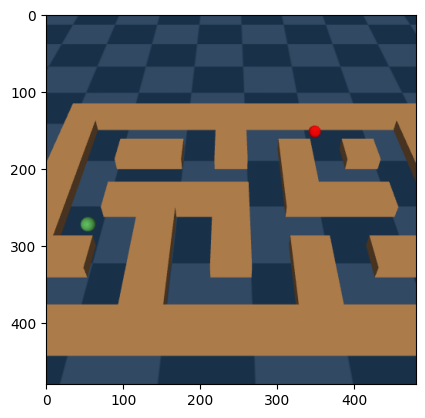

In [5]:
env.reset() 
img = env.render()
plt.imshow(img)
plt.show()

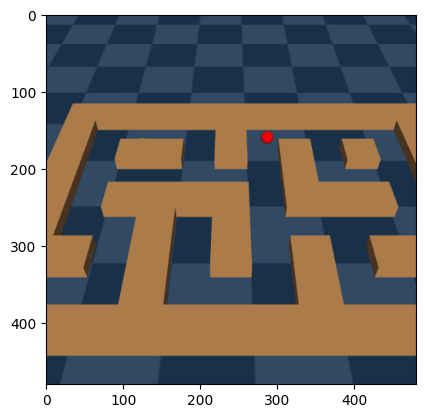

In [6]:
env.reset() 
img = env.render()
interval = 20 

img_height, img_weight, _ = img.shape
pixel_coords = world_to_image_coords(xy_states, img_width=img_weight, img_height=img_height)


plt.imshow(img)

#plt.plot(pixel_coords[:, 0], pixel_coords[:, 1], color="cyan", linewidth=2)
#plt.scatter(pixel_coords[::interval, 0], pixel_coords[::interval, 1], marker='^', color='limegreen', s=80, edgecolors='black', linewidths=0.5)

# Red stars for second half
#plt.scatter(part2[::interval, 0], part2[::interval, 1], marker='*', color='lightcoral', s=100, edgecolors='black', linewidths=0.5)

In [7]:
from models.cl_model import mlpCL
from data.DatasetCL import DatasetCL
from utils.tensor_utils import convert_batch_to_tensor
from utils.visualizations import visualize_embeddings

CHECKPOINT_PATH = os.getcwd() + "/saved_models"
print(CHECKPOINT_PATH)

c:\Users\ray\Documents\2025 RA\contrastive-learning-RL/saved_models


In [8]:
pretrained_filename = os.path.join(CHECKPOINT_PATH, 'reproduce_paper_laplace_v2_0.07temp.ckpt')
if os.path.isfile(pretrained_filename):
    print(f'Found pretrained model at {pretrained_filename}, loading...')
    model = mlpCL.load_from_checkpoint(pretrained_filename) # Automatically loads the model with the saved hyperparameters

In [9]:
mid = len(trajectory[0]) // 2
p1 = trajectory[0][:mid:interval]
p2 = trajectory[0][mid::interval]
t1 = torch.as_tensor(p1, dtype=torch.float32).to(device="cuda")
t2 = torch.as_tensor(p2, dtype=torch.float32).to(device="cuda")

model.eval() 
z1 = model.mlp(t1)

AssertionError: Torch not compiled with CUDA enabled

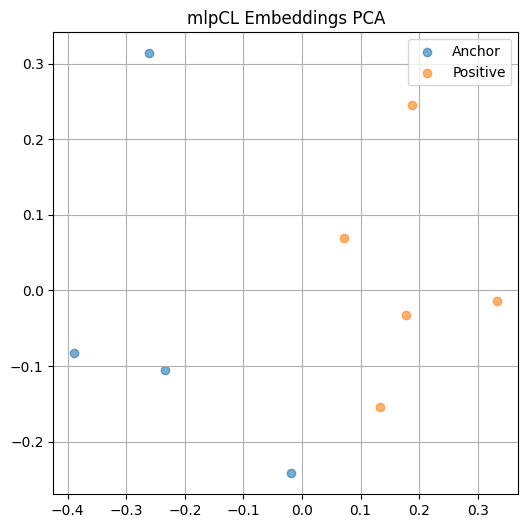

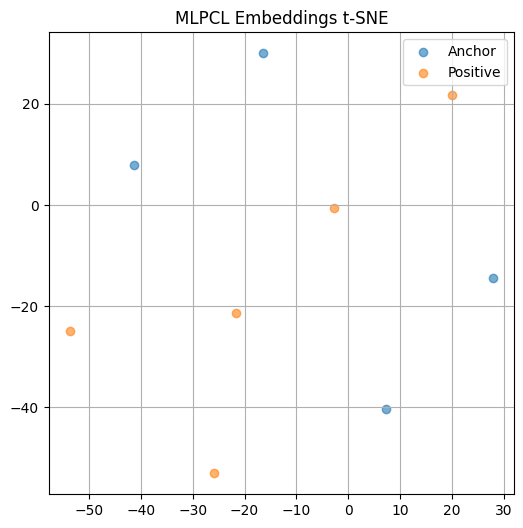

In [ ]:

visualize_embeddings(z1, method="pca", title="mlpCL Embeddings PCA")
visualize_embeddings(z1, method="tsne", title="MLPCL Embeddings t-SNE")


In [ ]:
"""
    def info_nce_loss(self, batch, mode="train"):
        # batch is of shape: [N, D]
        x = torch.cat(batch, dim=0)  # shape: [2N, D]

        z = F.normalize(self.mlp(x), dim=1)  # [2N, h4]
        N = z.size(0) // 2

        sim = torch.matmul(z, z.T) / self.hparams.temperature  # cosine sim matrix [2N, 2N]

        # mask out self similarities
        mask = torch.eye(2 * N, device=sim.device).bool()
        sim = sim.masked_fill_(mask, -9e15)

        # positives: i-th sample matches i + N mod 2N
        pos_idx = (torch.arange(2 * N, device=sim.device) + N) % (2 * N)
        labels = pos_idx

        loss = F.cross_entropy(sim, labels)

        # metrics
        preds = sim.argmax(dim=1)
        top1 = (preds == labels).float().mean()   # top1: true positive is most similar to anchor 
        top5 = (sim.topk(5, dim=1).indices == labels.unsqueeze(1)).any(dim=1).float().mean() # top5: true positive is atleast in the top 5 most similar to anchor 

        self.log(f"{mode}/nll_loss", loss, on_epoch=True, prog_bar=True)
        self.log(f"{mode}/top1", top1, on_epoch=True, prog_bar=True)
        self.log(f"{mode}/top5", top5, on_epoch=True, prog_bar=True)

        return loss

    """

In [ ]:
N= 4
a = (torch.arange(2 * N) + N) % (2 * N)
a

tensor([4, 5, 6, 7, 0, 1, 2, 3])

In [ ]:
b = torch.arange(10)
b

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
import minari
from data.TrajectorySet import TrajectorySet 
from data.Sampler import Sampler
from data.DatasetCL import DatasetCL
from utils.tensor_utils import split_data


MINARI_DATASET = minari.load_dataset("D4RL/pointmaze/large-v2") 
 
T = TrajectorySet(dataset=MINARI_DATASET)
S = Sampler(T, dist="l", b=3)

sampled_pairs = 8
ds = DatasetCL(S, num_state_pairs=sampled_pairs, k=2)
a = ds.get_batch()
a

t,v = split_data(a)

train_ds = DatasetCL(data=t, k=2)
val_ds = DatasetCL(data=v, k=2 )
train_ds[1]

(tensor([ 2.3901,  1.6906,  0.9351, -4.7953]),
 tensor([ 2.3808,  1.7385,  1.0493, -4.5680]))

In [ ]:
"""
maze_map = np.array(
    [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
     [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1], 
     [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1], 
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1], 
     [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1], 
     [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1], 
     [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1], 
     [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1], 
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
)

env_height, env_width = 480, 480
x_params = (-5.0, 5.0)
y_params = (-3.5, 3.5)

grid_points = visualizations.xy_to_grid(cluster_pts, x_params, y_params, env_height, env_width)
grid_points_2 = visualizations.xy_to_grid(cluster_test, x_params, y_params, env_height, env_width)

rows = [x[0] for x in grid_points]
cols = [x[1] for x in grid_points]

rows2 = [x[0] for x in grid_points_2]
cols2 = [x[1] for x in grid_points_2]
# === Plot ===
plt.imshow(maze_map, cmap="gray_r",
           extent=[0, env_width, 0, env_height], origin='upper')
plt.scatter(x = cols, y = rows, s=8, c="r")
plt.scatter(x = cols2, y = rows2, s=8, c="b")
plt.title("Cluster points on PointMaze Large (top-down)")

plt.show()
"""
